# Simplified Heterogeneous Graph Triage Pipeline

Objective

Turn process telemetry into a defensible session-level triage pipeline with simple baselines, a minimal process-file-parent graph, discovery scoring, and one-anchor steering evaluation.


In [ ]:
import warnings
import os
import tempfile
from itertools import combinations

os.environ.setdefault("NUMBA_CACHE_DIR", os.path.join(tempfile.gettempdir(), "numba_cache"))

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import average_precision_score
from umap import UMAP
import datamapplot
from IPython.display import display

warnings.filterwarnings("ignore", message=".*sysctlbyname.*")


In [2]:
SEED = 42
DATA_PATH = "../Data/train-process_uber_summary.parquet"
ROWS = 100_000

RARE_FILE_MIN_DEGREE = 2
RARE_FILE_MAX_DEGREE = 15
SESSION_INACTIVITY_THRESHOLD = pd.Timedelta(minutes=5)
MAX_SESSION_DURATION = pd.Timedelta(minutes=30)

EPOCHS = 8
HIDDEN = 48
OUT = 48
MAX_POS_PER_EDGE_TYPE = 5_000
K = 15
TOP_FRACTIONS = (0.01, 0.05, 0.10)
EXPERIMENT_SEEDS = (42, 43, 44)

np.random.seed(SEED)
torch.manual_seed(SEED)

### Development Dataframe Slice

In [3]:
def load_acme_slice(path=DATA_PATH, rows=ROWS):
    df = pd.read_parquet(path)
    df = df.copy()
    df["_time"] = pd.to_datetime(df["process_started"], errors="coerce", utc=True)
    df = (
        df[df["_time"].notna()]
        .sort_values("_time")
        .drop_duplicates("pid_hash", keep="first")
        .tail(rows)
        .reset_index(drop=True)
    )
    return df


def get_slice_manifest(df):
    return pd.DataFrame([{
        "source_file": os.path.basename(DATA_PATH),
        "row_count": len(df),
        "start_timestamps": (df["_time"].min()),
        "end_timestamps": (df["_time"].max()),
        "num_of_processes": df["pid_hash"].nunique(),
        "num_of_malicious_processes": df["red_team"].fillna(0).astype(int).sum(),
        # "num_of_sessions": df["session_id"].nunique(), # Don't know this since the graph creates sessions based on the connected components of the graph
        # "num_of_malicious_sessions": df["red_team"].fillna(0).astype(int).sum(), # Don't know this since the graph creates sessions based on the connected components of the graph
        "malicious_users_hosts": df[df["red_team"] == 1]["user_name"].drop_duplicates().shape[0] + df[df["red_team"] == 1]["hostname"].drop_duplicates().shape[0],
        "benign_users_hosts": df[df["red_team"] == 0]["user_name"].drop_duplicates().shape[0] + df[df["red_team"] == 0]["hostname"].drop_duplicates().shape[0],
        "session_inactivity_minutes": SESSION_INACTIVITY_THRESHOLD.total_seconds() / 60,
        "max_session_duration_minutes": MAX_SESSION_DURATION.total_seconds() / 60,
        "k": 15,
        "scaler": "StandardScaler",
        "feature_builder": "raw_session_stats",
        "git_commit": "N/A",
    }])

dev_df = load_acme_slice()
slice_manifest = get_slice_manifest(dev_df)
slice_manifest.to_csv("../artifacts/descriptions/development_slice_manifest.csv", index=False)

display(slice_manifest)


,source_file,row_count,start_timestamps,end_timestamps,num_of_processes,num_of_malicious_processes,malicious_users_hosts,benign_users_hosts,session_inactivity_minutes,max_session_duration_minutes,k,scaler,feature_builder,git_commit
0,train-process_uber_summary.parquet,100000,2024-09-18 20:45:15.961034+00:00,2024-09-22 23:57:33.487951+00:00,100000,31,2,13,5.0,30.0,15,StandardScaler,raw_session_stats,N/A


In [4]:
dev_df

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team,_time
0,0F7F5AC1B974A719B677ED5969708AEA,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,8932,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:15.961034+00:00
1,BF2413CE027AEB9022AA8E232DAD9D8A,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,7380,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:17.073633+00:00
2,3F4619640DE34982708D8A2AC6A81735,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,4172,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:18.185783+00:00
3,5E2F1973949C9472D8FB3A21DB59DA96,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,9704,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:19.295963+00:00
4,9269158EA34ECB01BF5D06E228C3DA2C,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,7784,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:20.521310+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,519C74F7310D49C295AEB7E0A0A55A3E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,EC2AMAZ-R9HHULK,14332,wmic.exe,1,os get version /format:list,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:56:28.864923+00:00
99996,4576D60FFC275C8ED9FA4E86EF505904,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,3000,wmic.exe,1,computersystem get dnshostname /value,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:57:33.145198+00:00
99997,1CDE178E919F23289A582CA992E6C02F,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,9116,wmic.exe,1,computersystem get domain /value,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:57:33.262588+00:00
99998,42474400004FA5634B780D79AAB4BC15,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,10284,wmic.exe,1,os get caption /format:list,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:57:33.386808+00:00


### Create Holdout Data Slice

In [5]:
holdout_df = load_acme_slice("../Data/test-process_uber_summary.parquet", rows=ROWS)

In [6]:
holdout_df

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team,_time
0,0461D93FFE260EAB781FB3520E7B70B2,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ZYQ,4412,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-07 17:52:33.408538+00:00
1,89FB41E9F68119288F93842CEE0206D7,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ZYQ,5532,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-07 17:52:34.766044+00:00
2,A17AD86B3AC98DA0C0021C7C7EF573EB,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ZYQ,8436,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-07 17:52:36.145088+00:00
3,5AB318329C127176487D2201B4E3746A,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ZYQ,5456,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-07 17:52:37.469091+00:00
4,D2679C6A0E69AECAFF9E4A6447B2D53B,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-ZYQ,8692,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-07 17:52:38.816364+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,148B2D3EA61BD6CCFE43F5CA32780D40,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-UIR,8276,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-09 06:59:53.690031+00:00
99996,6BA43E6702649C9A6A24870945E2F3DF,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-UIR,5500,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-09 06:59:54.996053+00:00
99997,D6567C5B57EDFFCF69315CB2B4416E19,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-UIR,4660,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-09 06:59:56.361288+00:00
99998,93001F2BE09FA86463BBEC52F0FA6EA2,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-UIR,9508,conhost.exe,1,0xffffffff -forcev1,1,...,NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-09 06:59:57.620498+00:00


### Full Set

In [7]:
# full_df = load_acme_slice(path=DATA_PATH, rows=len(pd.read_parquet(DATA_PATH)))
# full_df

## Strawman Baseline

In [8]:
# session raw stats -> StandardScaler -> kNN distance anomaly score

In [129]:
def make_strawman_sessions(dev_df):
    df = dev_df.sort_values("process_started").reset_index(drop=True).copy()
    df["process_started"] = pd.to_datetime(df["process_started"], errors="coerce", utc=True)

    user = df["user_name"].astype("string") if "user_name" in df else pd.Series(pd.NA, index=df.index)
    host = df["hostname"].astype("string") if "hostname" in df else pd.Series(pd.NA, index=df.index)
    df["session_identity"] = user.fillna("").where(user.fillna("") != "", "host:" + host.fillna("__missing__"))

    sessions = []
    session_ids = np.empty(len(df), dtype=int)
    next_session_id = 0

    for _, group in df.groupby("session_identity", sort=False):
        current = []
        session_start = None
        prev_time = None

        for idx, row in group.sort_values("process_started").iterrows():
            t = row["process_started"]

            new_session = (
                not current
                or (pd.notna(t) and pd.notna(prev_time) and t - prev_time > SESSION_INACTIVITY_THRESHOLD)
                or (pd.notna(t) and pd.notna(session_start) and t - session_start > MAX_SESSION_DURATION)
            )

            if new_session and current:
                sessions.append(current)
                next_session_id += 1
                current = []
                session_start = t

            if not current:
                session_start = t

            current.append(idx)
            session_ids[idx] = next_session_id
            prev_time = t

        if current:
            sessions.append(current)
            next_session_id += 1

    df["session_id"] = session_ids
    return df, sessions


# Numeric columns that are NOT safe to mean/std aggregate as "raw telemetry":
#   - id-like / label-encoded columns: averaging an arbitrary code (e.g. a hash
#     bucket or user-name encoding) has no magnitude meaning, and several of
#     these (num_user_name, num_parent_pid_hash) are identity in disguise,
#     which we will exclude from the baseline.
#   - label_* columns: these appear to be annotation/labeling metadata, not raw
#     telemetry, and risk label-leakage.
#   - sigma-hit and lolbas/mitre columns: these are outputs of *other* detection
#     logic (rule hits, technique matches), not raw process telemetry. Including
#     them would make the "raw stats" baseline informed by another
#     detector's opinion, however, this is worth including later on if we want.
STRAWMAN_EXCLUDE_ID_LIKE = {
    "num_agent_id", "os_pid", "num_process_name", "num_args", "num_user_name",
    "num_parent_pid_hash", "parent_os_pid", "num_parent_os_pid", "num_process_path",
    "num_file_md5", "num_file_sha2", "num_process_start", "num_process_stop",
}
STRAWMAN_EXCLUDE_EXACT = {"lolbas_num_rows", "mitre_num_rows"}


def strawman_numeric_columns(sessionized_df):
    return [
        c for c in sessionized_df.select_dtypes(include=[np.number]).columns
        if c not in {"session_id", "red_team"}
        and not c.startswith("label_")
        and not c.endswith("_sigma_hits")
        and not c.endswith("_sigma_rows")
        and c not in STRAWMAN_EXCLUDE_EXACT
        and c not in STRAWMAN_EXCLUDE_ID_LIKE
    ]


def build_raw_session_stats(sessionized_df):
    rows = []

    numeric_cols = strawman_numeric_columns(sessionized_df)

    for session_id, group in sessionized_df.groupby("session_id", sort=True):
        started = pd.to_datetime(group["process_started"], errors="coerce", utc=True)
        
        row = {
            "session_id": session_id,
            "session_size": len(group),
            "duration": (started.max() - started.min()).total_seconds() if started.notna().any() else 0.0,
            "unique_process_names": group["process_name"].nunique() if "process_name" in group else 0, # capture entropy of process names in a session to encode diversity of activity
            "unique_filenames": group["filename"].nunique() if "filename" in group else 0, # capture entropy of filenames in a session to encode diversity of activity
            "label": "malicious" if "red_team" in group and group["red_team"].fillna(False).astype(bool).any() else "benign",
        }

        for col in numeric_cols:
            row[f"{col}_mean"] = group[col].mean()
            row[f"{col}_std"] = group[col].std()

        rows.append(row)

    return pd.DataFrame(rows).fillna(0)


def knn_distance_anomaly_scores(X, k=15):
    X = np.asarray(X, dtype=np.float32)
    if len(X) <= 1:
        return np.zeros(len(X), dtype=float)

    qk = min(k + 1, len(X))
    dists, _ = cKDTree(X).query(X, k=qk, workers=-1)
    return np.asarray(dists[:, 1:]).mean(axis=1)

def malicious_neighbor_purity_diagnostic(X_scaled, session_table, k=15):
    """Measure whether malicious sessions are locally packed in the fixed representation.

    This is a label-aware representation diagnostic, not a deployable anomaly score.
    Labels are read only after X_scaled has already been built.
    """
    X_scaled = np.asarray(X_scaled, dtype=np.float32)
    is_malicious = (session_table["label"] == "malicious").to_numpy(dtype=bool)
    n_sessions = len(is_malicious)
    n_malicious = int(is_malicious.sum())

    if n_sessions <= 1 or n_malicious == 0:
        return pd.DataFrame([{
            "diagnostic": "malicious_neighbor_purity_at_k",
            "k": 0,
            "n_sessions": n_sessions,
            "n_malicious_sessions": n_malicious,
            "base_malicious_rate_excluding_self": np.nan,
            "malicious_neighbor_purity_at_k": np.nan,
            "median_malicious_neighbor_purity_at_k": np.nan,
            "malicious_sessions_with_any_malicious_neighbor_at_k": np.nan,
            "enrichment_vs_random": np.nan,
        }])

    effective_k = min(k, n_sessions - 1)
    _, indices = cKDTree(X_scaled).query(X_scaled, k=effective_k + 1, workers=-1)
    indices = np.asarray(indices)[:, 1:]
    neighbor_labels = is_malicious[indices]
    malicious_neighbor_purity = neighbor_labels[is_malicious].mean(axis=1)

    base_rate = (n_malicious - 1) / (n_sessions - 1)
    mean_purity = float(malicious_neighbor_purity.mean())

    return pd.DataFrame([{
        "diagnostic": "malicious_neighbor_purity_at_k",
        "k": effective_k,
        "n_sessions": n_sessions,
        "n_malicious_sessions": n_malicious,
        "base_malicious_rate_excluding_self": base_rate,
        "malicious_neighbor_purity_at_k": mean_purity,
        "median_malicious_neighbor_purity_at_k": float(np.median(malicious_neighbor_purity)),
        "malicious_sessions_with_any_malicious_neighbor_at_k": float((neighbor_labels[is_malicious].sum(axis=1) > 0).mean()),
        "enrichment_vs_random": mean_purity / base_rate if base_rate > 0 else np.nan,
    }])

def average_precision(y_true, y_scores):
    """Compute the average precision score for binary classification.
    
    Args: y_true (array-like): True binary labels (0 or 1).
          y_scores (array-like): Target scores. Larger continous kNN distance scores indicate more anomalous sessions. 
    """
    return average_precision_score(y_true, y_scores)

def reviews_to_first_malicious(y_true, y_scores):
    """Compute the number of reviews needed to find the first malicious session.
    
    Args:
        y_true (array-like): True binary labels (0 or 1).
        y_scores (array-like): Target scores. Larger continous kNN distance scores indicate more anomalous sessions.
    """
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores).astype(float)

    if y_true.sum() == 0:
        return np.nan
    
    order = np.argsort(-y_scores) # Sort in descending order of scores (more anomalous first)
    ranked_labels = y_true[order]

    first_hit = np.flatnonzero(ranked_labels == 1)  # Index of the first malicious session
    if len(first_hit) == 0:
        return np.nan  # No malicious sessions found
    
    return int(first_hit[0] + 1)  # +1 because we want the count of reviews, not the index

def random_expected_reviews_to_first(y_true):
    """Expected reviews to first malicious session under a random review order.

    For n sessions with m malicious sessions, the expected minimum rank of any
    malicious session under random ordering is (n + 1) / (m + 1).
    """
    y_true = np.asarray(y_true).astype(int)
    n_sessions = len(y_true)
    n_malicious = int(y_true.sum())

    if n_malicious == 0:
        return np.nan

    return (n_sessions + 1) / (n_malicious + 1)

def random_anomaly_scores(n_sessions, seed=SEED):
    """Deterministic random triage scores for a sanity-control baseline."""
    rng = np.random.default_rng(seed)
    return rng.random(n_sessions)

def ranking_at_k_metrics(y_true, y_scores, ks=(25, 50, 100, 250)):
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores).astype(float)

    order = np.argsort(-y_scores)
    ranked_labels = y_true[order]

    n_malicious = int(y_true.sum())
    metrics = {}

    for k in ks:
        top_k = min(k, len(ranked_labels))
        found = int(ranked_labels[:top_k].sum())

        metrics[f"found_at_{k}"] = found
        metrics[f"recall_at_{k}"] = found / n_malicious if n_malicious > 0 else np.nan
        metrics[f"precision_at_{k}"] = found / top_k if top_k > 0 else np.nan

    return metrics

session_df, sessions = make_strawman_sessions(dev_df)
session_df

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team,_time,session_identity,session_id
0,0F7F5AC1B974A719B677ED5969708AEA,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,8932,conhost.exe,1,0xffffffff -forcev1,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:15.961034+00:00,host:ACME-DC1,0
1,BF2413CE027AEB9022AA8E232DAD9D8A,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,7380,conhost.exe,1,0xffffffff -forcev1,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:17.073633+00:00,host:ACME-DC1,0
2,3F4619640DE34982708D8A2AC6A81735,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,4172,conhost.exe,1,0xffffffff -forcev1,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:18.185783+00:00,host:ACME-DC1,0
3,5E2F1973949C9472D8FB3A21DB59DA96,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,9704,conhost.exe,1,0xffffffff -forcev1,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:19.295963+00:00,host:ACME-DC1,0
4,9269158EA34ECB01BF5D06E228C3DA2C,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,7784,conhost.exe,1,0xffffffff -forcev1,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-18 20:45:20.521310+00:00,host:ACME-DC1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,519C74F7310D49C295AEB7E0A0A55A3E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,EC2AMAZ-R9HHULK,14332,wmic.exe,1,os get version /format:list,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:56:28.864923+00:00,host:EC2AMAZ-R9HHULK,1084
99996,4576D60FFC275C8ED9FA4E86EF505904,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,3000,wmic.exe,1,computersystem get dnshostname /value,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:57:33.145198+00:00,host:ACME-WS-PLU,1243
99997,1CDE178E919F23289A582CA992E6C02F,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,9116,wmic.exe,1,computersystem get domain /value,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:57:33.262588+00:00,host:ACME-WS-PLU,1243
99998,42474400004FA5634B780D79AAB4BC15,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,10284,wmic.exe,1,os get caption /format:list,1,...,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0,2024-09-22 23:57:33.386808+00:00,host:ACME-WS-PLU,1243


### Scoring

- KNN-based raw distance to identify and score anomalies, defined in ```knn_distance_anomaly_scores``` - to identify pure anomalies based on raw distance 
- Use ```malicious_neighbor_purity_diagnostic``` as a label-aware representation diagnostic after the raw feature space is fixed.
    - This checks whether malicious sessions are locally packed together in kNN space.
    - It is not a deployable anomaly score because it intentionally reads evaluation labels.

In [130]:
session_table = build_raw_session_stats(session_df)
session_table.loc[session_table["label"] == "malicious"]
feature_columns = [c for c in session_table.columns if c not in {"session_id", "label"}]

In [131]:
umapper = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=SEED
)

embeddings = umapper.fit_transform(session_table[feature_columns].values)

/work/home/mwasti/.conda/envs/STAMP2026/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<InteractiveFigure width=100% height=800>
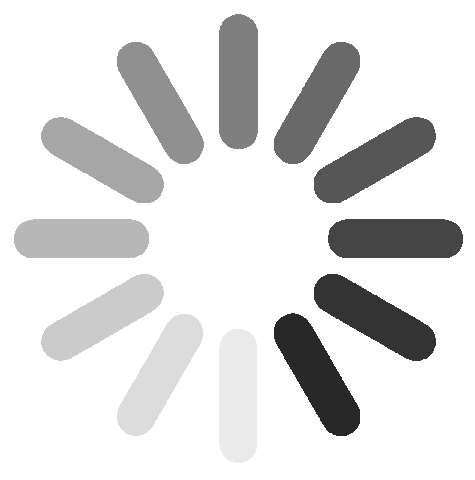

In [132]:
plot = datamapplot.create_interactive_plot(embeddings, session_table['label'].values, hover_text = session_table['label'].values, title="UMAP Projection of Sessions")
plot

## Graph Builder

The graph keeps process, file, parent-child, and temporal relations. Evaluation sessions use the same identity rule and split after five minutes of inactivity or 30 minutes total duration, preventing transitive multi-day components.

In [133]:
class TelemetryGraphBuilder:
    FEATURE_COLS = [
        # "duration_seconds",
        # "num_uniq_file_hash",
        # "net_total_events",
        # "conn_id_count",
        # "reg_totals",
    ]

    FEATURE_NAMES = [
        # "duration",
        # "num_file_hash",
        # "net_events",
        # "conn_id_count",
        # "reg_totals",
    ]

    def __init__(
        self,
        rare_file_min_degree=RARE_FILE_MIN_DEGREE,
        rare_file_max_degree=RARE_FILE_MAX_DEGREE,
    ):
        self.rare_file_min_degree = rare_file_min_degree
        self.rare_file_max_degree = rare_file_max_degree

    def build(self, df):
        self.df = df.copy().reset_index(drop=True)
        
        # Process the dataframe for use in graph construction
        self.df["process_started"] = pd.to_datetime(self.df["process_started"], errors="coerce", utc=True)
        self.process_ids = self.df["pid_hash"].tolist()

        # Create a mapping from process IDs to their corresponding indices in the graph
        self.node_index = {pid: i for i, pid in enumerate(self.process_ids)}
        self.file_index = {}

        # Contain Parent to Child Edges and File Touches Edges
        self.parent_child_edges = []
        self.touches_edges = []

        # Mapping from files to the processes that touch them
        self.file_to_processes = {}

        # Add edges for parent-child relationships, and file touches
        self._add_parent_child_edges()
        self._add_file_edges()

        data = self._to_heterodata()
        self.sessions = self._extract_bounded_sessions()
        data["process"].session_id = self._session_id_tensor(len(self.process_ids), self.sessions)
        return data

    def _process_features(self):
        X = self.df[self.FEATURE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=np.float32)
        return torch.tensor(X, dtype=torch.float)

    # def _process_labels(self):
    #     y = pd.to_numeric(self.df["red_team"], errors="coerce").fillna(0).astype(int).to_numpy()
    #     return torch.tensor(y, dtype=torch.long)

    def _add_parent_child_edges(self):
        for row in self.df.itertuples(index=False):
            parent = getattr(row, "parent_pid_hash")
            child = getattr(row, "pid_hash")
            if pd.notna(parent) and parent in self.node_index and child in self.node_index:
                self.parent_child_edges.append((self.node_index[parent], self.node_index[child]))

    def _add_file_edges(self):
        file_counts = self.df["filename"].dropna().value_counts()
        rare_files = set(file_counts[
            (file_counts >= self.rare_file_min_degree) &
            (file_counts <= self.rare_file_max_degree)
        ].index)

        for row in self.df.itertuples(index=False):
            fname = getattr(row, "filename")
            pid = getattr(row, "pid_hash")
            if pd.isna(fname) or fname not in rare_files or pid not in self.node_index:
                continue
            if fname not in self.file_index:
                self.file_index[fname] = len(self.file_index)
            pidx = self.node_index[pid]
            fidx = self.file_index[fname]
            self.touches_edges.append((pidx, fidx))
            self.file_to_processes.setdefault(fname, []).append(pidx)

    def _edge_tensor(self, edges):
        return torch.tensor(edges, dtype=torch.long).t().contiguous()

    def _to_heterodata(self):
        data = HeteroData()
        data["process"].x = self._process_features()
        # data["process"].y = self._process_labels()
        data["file"].x = torch.ones((len(self.file_index), 1), dtype=torch.float)

        if self.parent_child_edges:
            data["process", "parent_child", "process"].edge_index = self._edge_tensor(self.parent_child_edges)
        if self.touches_edges:
            ei = self._edge_tensor(self.touches_edges)
            data["process", "touches", "file"].edge_index = ei
            data["file", "touched_by", "process"].edge_index = ei.flip(0)
        return data

    def _extract_bounded_sessions(self):
        work = self.df[["hostname", "user_name", "process_started"]].copy()
        work["node_id"] = np.arange(len(work))
        work["session_host"] = work["hostname"]
        missing_host = work["session_host"].isna()
        work.loc[missing_host, "session_host"] = (
            "__missing_host_" + work.loc[missing_host, "node_id"].astype(str)
        )
        work["session_identity"] = work["user_name"].fillna("__host_activity__")
        work = work.sort_values(
            ["session_host", "session_identity", "process_started"],
            kind="mergesort",
        )

        sessions = []
        grouped = work.groupby(
            ["session_host", "session_identity"],
            sort=False,
            dropna=False,
        )
        for _, group in grouped:
            current = []
            session_start = None
            previous_time = None

            for event_time, node_id in group[["process_started", "node_id"]].itertuples(
                index=False,
                name=None,
            ):
                should_split = current and (
                    event_time - previous_time > SESSION_INACTIVITY_THRESHOLD
                    or event_time - session_start > MAX_SESSION_DURATION
                )
                if should_split:
                    sessions.append(current)
                    current = []
                    session_start = None

                if not current:
                    session_start = event_time
                current.append(int(node_id))
                previous_time = event_time

            if current:
                sessions.append(current)

        return sorted(sessions, key=lambda session: session[0])


    def _session_id_tensor(self, n_processes, sessions):
        ids = np.empty(n_processes, dtype=np.int64)
        for sid, session in enumerate(sessions):
            ids[session] = sid
        return torch.tensor(ids, dtype=torch.long)


builder = TelemetryGraphBuilder()
graph_data = builder.build(dev_df)
sessions = builder.sessions
process_df = dev_df.set_index("pid_hash").reindex(builder.process_ids).reset_index()

session_sizes = np.asarray([len(session) for session in sessions])
session_spans = np.asarray([
    (
        process_df.loc[session, "_time"].max()
        - process_df.loc[session, "_time"].min()
    ).total_seconds() / 60.0
    for session in sessions
])

session_sizes = np.asarray([len(session) for session in sessions])
session_spans = np.asarray([
    (
        process_df.loc[session, "_time"].max()
        - process_df.loc[session, "_time"].min()
    ).total_seconds() / 60.0
    for session in sessions
])

build_summary = pd.DataFrame([{
    "process_nodes": graph_data["process"].num_nodes,
    "file_nodes": graph_data["file"].num_nodes,
    "edge_types": len(graph_data.edge_types),
    "sessions": len(sessions),
    # "malicious_sessions": int(sum(any(graph_data["process"].y[n].item() == 1 for n in s) for s in sessions)),
    "median_session_size": float(np.median(session_sizes)),
    "p95_session_size": float(np.quantile(session_sizes, 0.95)),
    "max_session_size": int(session_sizes.max()),
    "p95_session_minutes": float(np.quantile(session_spans, 0.95)),
    "max_session_minutes": float(session_spans.max()),
    "parent_child_edges": len(builder.parent_child_edges),
    "touches_edges": len(builder.touches_edges),
}])

display(build_summary)

,process_nodes,file_nodes,edge_types,sessions,median_session_size,p95_session_size,max_session_size,p95_session_minutes,max_session_minutes,parent_child_edges,touches_edges
0,100000,14,3,3131,2.0,137.0,213,29.998144,29.999997,2318,66


## Metric Evaluator

In [134]:
def evaluate_precomputed_scores(y_true, y_scores):
    metrics = {
        "average_precision": average_precision(y_true, y_scores),
        "reviews_to_first_malicious": reviews_to_first_malicious(y_true, y_scores),
        "random_expected_reviews_to_first": random_expected_reviews_to_first(y_true),
    }
    metrics["ranking_at_k_metrics"] = ranking_at_k_metrics(y_true, y_scores, ks=(25, 50, 100, 250))
    return metrics

def metric_summary_from_method_results(method_results):
    rows = []

    for method_name, metrics in method_results.items():
        row = {
            "method": method_name,
            "average_precision": metrics.get("average_precision"),
            "reviews_to_first_malicious": metrics.get("reviews_to_first_malicious"),
            "random_expected_reviews_to_first": metrics.get("random_expected_reviews_to_first"),
        }
        row.update(metrics.get("ranking_at_k_metrics", {}))
        rows.append(row)

    return pd.DataFrame(rows)

def triage_metric_eval(features, session_table, k=15):
    """Runs the baseline metric evaluation on the given features and returns the results.
    
    Args:
        features (pd.DataFrame): The features to evaluate - should be directly passable to the scaler and anomaly scoring functions.
        session_table (pd.DataFrame): The session table to update with anomaly scores.
    """

    triage_metrics = {
        "average_precision": None,
        "reviews_to_first_malicious": None,
        "random_expected_reviews_to_first": None,
        "ranking_at_k_metrics": None,
        "raw_distance_scores": None,
        "anomaly_distance_z_scores": None,
        "representation_diagnostic": None,
    }


    y_true = session_table["label"].map({"malicious": 1, "benign": 0}).to_numpy(dtype=int)

    triage_metrics["raw_distance_scores"] = knn_distance_anomaly_scores(features, k)
    session_table["raw_session_stats_knn"] = triage_metrics["raw_distance_scores"]

    triage_metrics["average_precision"] = average_precision(y_true, triage_metrics["raw_distance_scores"])
    triage_metrics["reviews_to_first_malicious"] = reviews_to_first_malicious(y_true, triage_metrics["raw_distance_scores"])
    triage_metrics["random_expected_reviews_to_first"] = random_expected_reviews_to_first(y_true)
    triage_metrics["ranking_at_k_metrics"] = ranking_at_k_metrics(y_true, triage_metrics["raw_distance_scores"], ks=(25, 50, 100, 250))

    # The distance ranking is our anomaly score, so we can sort the sessions by this score to identify the most anomalous sessions
    display(session_table["raw_session_stats_knn"].describe()) # Showing massive outliers, the max is ~100x the 75th percentile
    display(session_table["raw_session_stats_knn"].sort_values(ascending=False).head(10)) # Massive distances between top sessions, meaning there are distinct outliers

    # To make this more human interpretable, we will use Z-scores to identify which features are driving the anomaly score for the top anomalous session.
    triage_metrics["anomaly_distance_z_scores"] = pd.DataFrame((triage_metrics["raw_distance_scores"] - np.mean(triage_metrics["raw_distance_scores"])) / np.std(triage_metrics["raw_distance_scores"]), columns=["anomaly_distance_z_scores"])
    display(triage_metrics["anomaly_distance_z_scores"])

    # Label-aware representation diagnostic: are malicious sessions packed together in this feature space?
    triage_metrics["representation_diagnostic"] = malicious_neighbor_purity_diagnostic(features, session_table, k)
    display(triage_metrics["representation_diagnostic"])

    return triage_metrics

## Pipeline Entry Point

In [135]:
def run_triage_methods(config):

    ### Prepare Data ###
    # Load the development slice of the data
    dev_df = load_acme_slice()
    slice_manifest = get_slice_manifest(dev_df)
    # slice_manifest.to_csv("../artifacts/descriptions/development_slice_manifest.csv", index=False)

    session_tables = {}
    output_scores = {}

    for method_name, method_func in config.items():
        if method_name == "random_score_baseline":
            ### Run Random Scoring Baseline ###
            sessionized_df, sessions = make_strawman_sessions(dev_df)
            session_tables[method_name] = build_raw_session_stats(sessionized_df)

            y_true = session_tables[method_name]["label"].map({"malicious": 1, "benign": 0}).to_numpy(dtype=int)
            
            random_scores = random_anomaly_scores(len(session_tables[method_name]), seed=SEED)
            session_tables[method_name]["random_score"] = random_scores

            output_scores[method_name] = evaluate_precomputed_scores(y_true, random_scores)
        
        elif method_name == "raw_session_baseline":
            ### Run Strawman Sessionization and Raw Session Stats ###

            # Create a session table with raw session statistics
            sessionized_df, sessions = method_func(dev_df)
            session_tables[method_name] = build_raw_session_stats(sessionized_df)

            # Get the feature columns for scoring, excluding session_id and label
            feature_columns = [c for c in session_tables[method_name].columns if c not in {"session_id", "label"}]

            # Score on the raw session stats using StandardScaler and kNN anomaly scores
            X = StandardScaler().fit_transform(session_tables[method_name][feature_columns])

            # Scoring

            # Get back a dictionary of triage metrics, including recall, percision, reviews to retrival, anomaly distance z-scores and representation diagnostics
            triage_metrics = triage_metric_eval(X, session_tables[method_name])
            output_scores[method_name] = triage_metrics


        elif method_name == "graph_session_baseline":
            ### Run Graph Sessionization ###
            graph_builder = method_func
            graph_builder.build(dev_df)
            sessions = graph_builder.sessions
            # session_tables[method_name] = graph_builder.session_stats(graph_builder, dev_df)

            X = None

            # Get back a dictionary of triage metrics, including recall, percision, reviews to retrival, anomaly distance z-scores and representation diagnostics
            triage_metrics = triage_metric_eval(X, session_tables[method_name], k=15)
            output_scores[method_name] = triage_metrics

    
    metric_summary = metric_summary_from_method_results(output_scores)

    results = {
        "slice_manifest": slice_manifest,
        "session_table": session_tables,
        "triage_metrics_per_method": output_scores,
        "metric_summary": metric_summary,
    }

    return dev_df, results


graph_builder = TelemetryGraphBuilder()
methods_config = {
    "random_score_baseline": None,
    "raw_session_baseline": make_strawman_sessions,
    # "graph_session_baseline": graph_builder,
}

dev_df, results = run_triage_methods(methods_config)

count    1457.000000
mean        3.016148
std         8.749429
min         0.539398
25%         1.070602
50%         1.603439
75%         2.398985
max       239.544023
Name: raw_session_stats_knn, dtype: float64

1294    239.544023
513     144.003089
506      65.312406
1362     56.404498
32       54.024441
161      53.749397
488      42.293852
558      40.640419
835      38.089992
12       35.424416
Name: raw_session_stats_knn, dtype: float64

,anomaly_distance_z_scores
0,-0.010503
1,0.028106
2,-0.124306
3,-0.117825
4,0.490602
...,...
1452,-0.026515
1453,-0.162031
1454,-0.072907
1455,-0.168537


,diagnostic,k,n_sessions,n_malicious_sessions,base_malicious_rate_excluding_self,malicious_neighbor_purity_at_k,median_malicious_neighbor_purity_at_k,malicious_sessions_with_any_malicious_neighbor_at_k,enrichment_vs_random
0,malicious_neighbor_purity_at_k,15,1457,19,0.012363,0.207018,0.266667,0.842105,16.745419


In [136]:
results['metric_summary']

,method,average_precision,reviews_to_first_malicious,random_expected_reviews_to_first,found_at_25,recall_at_25,precision_at_25,found_at_50,recall_at_50,precision_at_50,found_at_100,recall_at_100,precision_at_100,found_at_250,recall_at_250,precision_at_250
0,random_score_baseline,0.014803,47,72.9,0,0.0,0.0,1,0.052632,0.02,1,0.052632,0.01,3,0.157895,0.012
1,raw_session_baseline,0.016299,128,72.9,0,0.0,0.0,0,0.000000,0.00,0,0.000000,0.00,2,0.105263,0.008


In [126]:
results['triage_metrics_per_method']

{'random_score_baseline': {'average_precision': 0.05561558196606264,
  'reviews_to_first_malicious': 3,
  'random_expected_reviews_to_first': 72.9,
  'ranking_at_k_metrics': {'found_at_25': 3,
   'recall_at_25': 0.15789473684210525,
   'precision_at_25': 0.12,
   'found_at_50': 3,
   'recall_at_50': 0.15789473684210525,
   'precision_at_50': 0.06,
   'found_at_100': 3,
   'recall_at_100': 0.15789473684210525,
   'precision_at_100': 0.03,
   'found_at_250': 5,
   'recall_at_250': 0.2631578947368421,
   'precision_at_250': 0.02},
  'raw_distance_scores': array([0.00187401, 0.00249678, 0.00239778, ..., 0.00417413, 0.00263277,
         0.00485122], shape=(1457,)),
  'anomaly_distance_z_scores':       anomaly_distance_z_scores
  0                     -1.145243
  1                     -0.342208
  2                     -0.469871
  3                      0.973871
  4                     -1.561133
  ...                         ...
  1452                   0.504118
  1453                  -0.029

In [ ]:
results["slice_manifest"]

,source_file,row_count,start_timestamps,end_timestamps,num_of_processes,num_of_malicious_processes,malicious_users_hosts,benign_users_hosts,session_inactivity_minutes,max_session_duration_minutes,k,scaler,feature_builder,git_commit
0,train-process_uber_summary.parquet,100000,2024-09-18 20:45:15.961034+00:00,2024-09-22 23:57:33.487951+00:00,100000,31,2,13,5.0,30.0,15,StandardScaler,raw_session_stats,N/A
